# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zayer1/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Action Taxonomy & Business Rules:**
We translate our raw XGBoost probabilities into four human-readable actions based on probability confidence, positional visibility (Archetype), and search volume (Cost/Value analysis).

*   **Urgent Refresh:** High decay risk (`prob >= 0.7`) + High visibility target (`Page 1` or `Striking Distance`).
*   **Standard Review:** High decay risk (`prob >= 0.7`) + Lower visibility.
*   **Monitor:** Natural decay lifecycle (e.g., News articles / `feedly article`).
*   **Ignore:** No traffic value (`search_volume < 100` or 0 impressions). This prevents wasting expensive editorial time on dead pages (The Basement Trap).

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Load data and replicate the Week 5 model to get probabilities
data_path = '../../data/raw/content_refresh_anonymized.csv'
df = pd.read_csv(data_path)

df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)
DROP_FOR_TRAIN = [
    'client_id', 'content_id', 'trend_direction', 'trend_pct', 'is_declining_label',
    'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d',
    'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 
    'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d'
]

X = df.drop(columns=DROP_FOR_TRAIN)
y = df['is_declining_label']

cat_cols = X.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    X[col] = X[col].astype('category')

model = xgb.XGBClassifier(random_state=42, enable_categorical=True, max_depth=3, n_estimators=100)
model.fit(X, y)
df['probability'] = model.predict_proba(X)[:, 1]

# 2. Define the Playbook Business Rules mapping Archetype -> Action
def assign_action(row):
    # Cost/Value check: Don't spend expensive editorial time on zero-value pages
    if row['search_volume'] < 100 or row['impressions_90d'] == 0:
        return pd.Series(['Ignore', 'No Traffic Value (Basement Trap)'])
    
    # Natural Decay override
    elif row['content_type'] == 'feedly article':
        return pd.Series(['Monitor', 'Natural Decay (News update)'])
        
    # High-Value Triggers
    elif row['probability'] >= 0.7:
        if row['position_tier'] in ['page_1', 'striking']:
            return pd.Series(['Urgent Refresh', 'High Decay Risk on High-Visibility Target'])
        else:
            return pd.Series(['Standard Review', 'High Decay Risk'])
            
    # Safe Bucket
    return pd.Series(['None', 'Stable Traffic'])

# Apply logic
df[['recommended_action', 'reason_code']] = df.apply(assign_action, axis=1)

print("Playbook Actions Assigned Successfully.")
print(df['recommended_action'].value_counts())


Playbook Actions Assigned Successfully.
recommended_action
Ignore             24483
None                2527
Monitor             2096
Urgent Refresh       609
Standard Review      285
Name: count, dtype: int64


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended Use:** 
This Playbook is designed strictly as a prioritization engine for human editorial workflows. It helps marketing managers allocate writing resources to the most vulnerable, high-value pages. It assumes that a "refresh" involves a substantive editorial update, not a superficial CMS typo fix.

**Limits (The Basement Trap):**
The underlying model predicts decay based on a mathematical formula that requires a 20% drop in impressions. Therefore, the model is completely blind to pages that already have zero traffic, because they cannot drop any further. The model will incorrectly label these dead pages as "Safe". Our `assign_action()` logic mitigates this by aggressively flagging them as `Ignore`. Below is the mathematical proof of this limitation in the dataset.

In [2]:
# Mathematical proof of the Basement Trap limitation
basement_pages = df[df['impressions_prev_30d'] == 0]
print(f"Total pages with 0 prior traffic: {len(basement_pages)}")
print("\nLabel distribution for Basement Pages:")
print(basement_pages['is_declining_label'].value_counts(normalize=True).map('{:.1%}'.format))
print("\nBecause they physically cannot drop 20%, the label forces 100.0% of them to be 'Safe'.")


Total pages with 0 prior traffic: 3388

Label distribution for Basement Pages:
is_declining_label
0    100.0%
Name: proportion, dtype: object

Because they physically cannot drop 20%, the label forces 100.0% of them to be 'Safe'.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**The No-Go List:**
This ML-driven queue must NEVER be used to automatically delete URLs or issue automated 301 redirects. Page deletion requires human SEO context (e.g., checking backlinks and internal site architecture). 

**Human Review (Natural Decay):**
Not all decay is a failure. News syndications (`feedly article`) naturally decay as they become outdated. We explicitly intercepted these and overrode the model to prevent humans from wasting time "fixing" them. Below is the proof of the playbook intercepting these false alarms.

In [3]:
# Show the human review override in action
print("Playbook Override Results (Pages intercepted before hitting a human queue):")
intercepted = len(df[df['reason_code'] == 'Natural Decay (News update)'])
print(f"Intercepted {intercepted} 'feedly article' pages that were naturally decaying.")
print("\nFull Reason Code Distribution:")
print(df['reason_code'].value_counts())


Playbook Override Results (Pages intercepted before hitting a human queue):
Intercepted 2096 'feedly article' pages that were naturally decaying.

Full Reason Code Distribution:
reason_code
No Traffic Value (Basement Trap)             24483
Stable Traffic                                2527
Natural Decay (News update)                   2096
High Decay Risk on High-Visibility Target      609
High Decay Risk                                285
Name: count, dtype: int64


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Light Monitoring Triggers:**
If FlyRank's global traffic baseline drops significantly (e.g., resulting from a massive Google Core Algorithm update), the historical training data is instantly invalidated. If the medians below shift by more than 20% in production, the XGBoost model must be retrained on a new post-update dataset.

In [4]:
# Establish baseline ground truth for MLOps drift monitoring
print("=== BASELINE METRICS FOR MLOps DRIFT MONITORING ===")
print(f"Median previous 30d impressions: {df['impressions_prev_30d'].median()}")
print(f"Mean previous 30d impressions:   {df['impressions_prev_30d'].mean():.2f}")
print(f"Median search volume:            {df['search_volume'].median()}")


=== BASELINE METRICS FOR MLOps DRIFT MONITORING ===
Median previous 30d impressions: 210.0
Mean previous 30d impressions:   1783.08
Median search volume:            10.0


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported action_queue.csv with 894 prioritized pages.


Exported action_distribution.png.


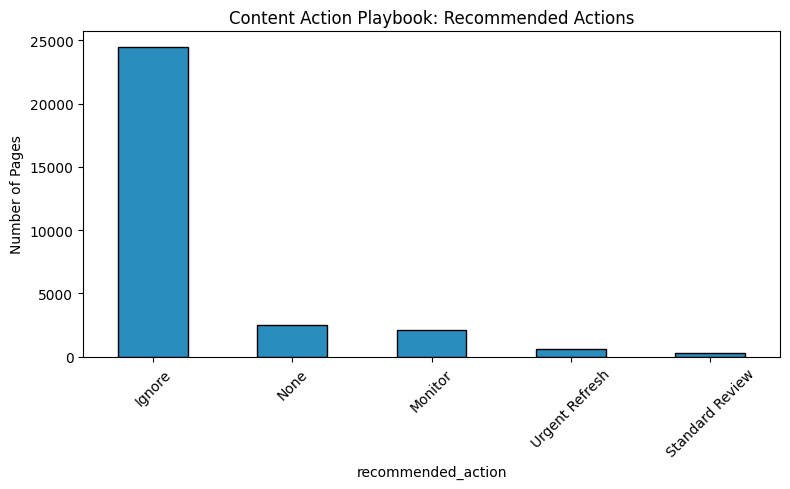

In [5]:
# Filter and sort the final actionable queue
actionable_queue = df[df['recommended_action'].isin(['Urgent Refresh', 'Standard Review'])]
final_queue = actionable_queue.sort_values(by='probability', ascending=False)

# Export to CSV (This stays out of Git to prevent data leaks)
os.makedirs('../../work/outputs', exist_ok=True)
final_queue.to_csv('../../work/outputs/action_queue.csv', index=False)
print(f"Exported action_queue.csv with {len(final_queue)} prioritized pages.")

# Generate and export chart
os.makedirs('../../work/figures', exist_ok=True)
plt.figure(figsize=(8, 5))
df['recommended_action'].value_counts().plot(kind='bar', color='#2b8cbe', edgecolor='black')
plt.title("Content Action Playbook: Recommended Actions")
plt.ylabel("Number of Pages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../work/figures/action_distribution.png')
print("Exported action_distribution.png.")
plt.show()


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.